<a href="https://colab.research.google.com/github/rajat805/rajat805/blob/main/Another_copy_of_Sample_ML_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Marketing Campaign



##### **Project Type**    - Classification


# **Project Summary -**

This project focused on predicting whether a customer would respond positively to a marketing campaign using machine learning classification techniques. The dataset contained customer demographic information, purchasing behavior, previous campaign responses, and spending patterns. The target variable, Response, indicated whether a customer accepted the marketing campaign.

The project began with data understanding, followed by data quality assessment to identify missing values, duplicate records, data types, unique values, and class imbalance. Data wrangling was then performed by handling missing values, converting date columns, removing unnecessary features, and creating new features such as Age, Total Spending, Total Purchases, Customer Tenure, and Total Children through feature engineering.

Exploratory Data Analysis (EDA) was conducted using various visualizations, including histograms, scatter plots, line charts, pie charts, box plots, heatmaps, and pair plots. The analysis revealed that customer income, spending behavior, previous campaign acceptance, and purchasing patterns were strongly associated with campaign response.

Since the dataset was imbalanced, with approximately 85% non-responders and 15% responders, SMOTE (Synthetic Minority Oversampling Technique) was applied to the training data to improve the model's ability to identify positive responses.

Four classification algorithms were developed and evaluated: Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors (KNN). Their performance was compared using Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Confusion Matrix, and Classification Report.

Among all the evaluated models, Logistic Regression trained on SMOTE-balanced data achieved the best balance for the business objective by producing the highest Recall (73.13%), highest F1-Score (56.65%), and highest ROC-AUC (87.96%). Although Random Forest achieved higher accuracy, Logistic Regression with SMOTE was selected because it identified a significantly larger number of customers who were likely to respond to the marketing campaign.

The developed model can assist businesses in identifying potential customers, improving campaign effectiveness, reducing unnecessary marketing costs, and supporting data-driven marketing decisions.

# **GitHub Link -**

https://github.com/rajat805

# **Problem Statement**


* To develop a machine learning classification model that predicts whether a customer will respond positively to a marketing campaign based on customer demographics, purchasing behavior, and previous campaign interactions. The model aims to help businesses identify potential customers, improve marketing effectiveness, reduce unnecessary promotional costs, and support data-driven decision-making.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


### Dataset Loading

In [18]:
# Load Dataset

df = pd.read_excel("/content/marketing_campaign (1).xlsx")

print("Dataset loaded successfully.")
display(df.head())

Dataset loaded successfully.


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


### Dataset First View

In [7]:
# Dataset First Look
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


### Dataset Rows & Columns count

In [8]:
# Dataset Rows & Columns count
rows = df.shape[0]
coloumns = df.shape[1]
print("rows:", rows)
print("coloumns:", coloumns)

rows: 2240
coloumns: 29


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [10]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


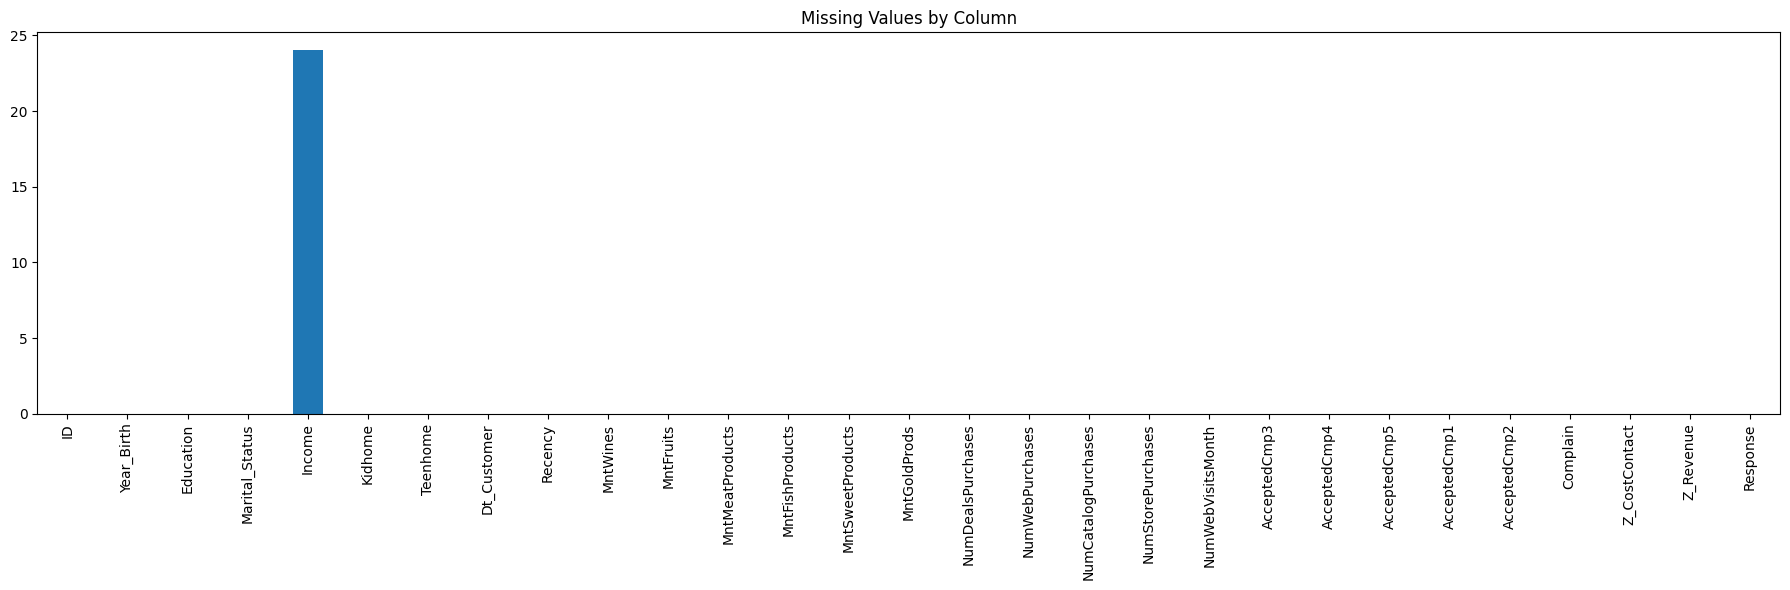

In [12]:


import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))
df.isnull().sum().plot(kind='bar')
plt.xticks(rotation=90)
plt.title("Missing Values by Column")
plt.tight_layout()
plt.show()

## ***2. Understanding Your Variables***

In [14]:
# Dataset Columns
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [5]:
# Dataset Describe
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()

,0
ID,2240
Year_Birth,59
Education,5
Marital_Status,8
Income,1974
Kidhome,3
Teenhome,3
Dt_Customer,663
Recency,100
MntWines,776


## 3. ***Data Wrangling***

### Data Wrangling Code

In [24]:
# Write your code to make your dataset analysis ready.
# Numerical Columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical Columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features ({len(num_cols)}):")
print(num_cols)

print("\n")

print(f"Categorical Features ({len(cat_cols)}):")
print(cat_cols)

Numerical Features (26):
['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


Categorical Features (3):
['Education', 'Marital_Status', 'Dt_Customer']


In [23]:
# ==========================================================
# PHASE 3 : DATA WRANGLING
# ==========================================================

print("="*80)
print("DATA WRANGLING STARTED")
print("="*80)


# ----------------------------------------------------------
# 1. Create Copy of Original Dataset
# ----------------------------------------------------------

df_clean = df.copy()

print("Original Dataset Shape:", df_clean.shape)


# ----------------------------------------------------------
# 2. Handle Missing Values
# ----------------------------------------------------------

print("\nHandling Missing Values...")
print("-"*80)

# Check missing values before treatment
missing_before = df_clean.isnull().sum()

display(
    missing_before[missing_before > 0]
)


# Fill Income missing values using Median

if 'Income' in df_clean.columns:

    median_income = df_clean['Income'].median()

    df_clean['Income'] = df_clean['Income'].fillna(median_income)

    print(
        f"Income missing values filled with median: {median_income}"
    )


# ----------------------------------------------------------
# 3. Convert Date Column
# ----------------------------------------------------------

print("\nConverting Date Column...")
print("-"*80)


df_clean['Dt_Customer'] = pd.to_datetime(
    df_clean['Dt_Customer'],
    errors='coerce'
)

print("Date conversion completed.")



# ----------------------------------------------------------
# 4. Remove Constant Columns
# ----------------------------------------------------------

print("\nRemoving Constant Columns...")
print("-"*80)


constant_cols = [
    'Z_CostContact',
    'Z_Revenue'
]


for col in constant_cols:
    if col in df_clean.columns:
        df_clean.drop(columns=col, inplace=True)


print("Removed Constant Columns:", constant_cols)



# ----------------------------------------------------------
# 5. Remove ID Column
# ----------------------------------------------------------

print("\nRemoving Customer ID...")
print("-"*80)


if 'ID' in df_clean.columns:
    df_clean.drop(columns=['ID'], inplace=True)

print("ID column removed.")



# ----------------------------------------------------------
# 6. Outlier Detection (IQR Method)
# ----------------------------------------------------------

print("\nOutlier Detection using IQR Method")
print("-"*80)


num_cols = df_clean.select_dtypes(
    include=np.number
).columns


outlier_summary = []


for col in num_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1


    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR


    outliers = (
        (df_clean[col] < lower_limit) |
        (df_clean[col] > upper_limit)
    ).sum()


    outlier_summary.append(
        [col, outliers]
    )


outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        'Feature',
        'Number of Outliers'
    ]
)


display(
    outlier_df.sort_values(
        by='Number of Outliers',
        ascending=False
    )
)



# ----------------------------------------------------------
# 7. Final Data Quality Check
# ----------------------------------------------------------

print("\nFINAL DATA QUALITY CHECK")
print("-"*80)


print("Dataset Shape:")
print(df_clean.shape)


print("\nMissing Values Remaining:")
print(df_clean.isnull().sum().sum())


print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())


print("\nData Types:")
display(df_clean.dtypes)


print("\nFirst 5 Rows:")
display(df_clean.head())


print("="*80)
print("DATA WRANGLING COMPLETED SUCCESSFULLY")
print("="*80)

DATA WRANGLING STARTED
Original Dataset Shape: (2240, 29)

Handling Missing Values...
--------------------------------------------------------------------------------


,0
Income,24


Income missing values filled with median: 51381.5

Converting Date Column...
--------------------------------------------------------------------------------
Date conversion completed.

Removing Constant Columns...
--------------------------------------------------------------------------------
Removed Constant Columns: ['Z_CostContact', 'Z_Revenue']

Removing Customer ID...
--------------------------------------------------------------------------------
ID column removed.

Outlier Detection using IQR Method
--------------------------------------------------------------------------------


,Feature,Number of Outliers
22,Response,334
9,MntSweetProducts,248
6,MntFruits,227
8,MntFishProducts,223
10,MntGoldProds,207
7,MntMeatProducts,175
17,AcceptedCmp4,167
16,AcceptedCmp3,163
18,AcceptedCmp5,163
19,AcceptedCmp1,144



FINAL DATA QUALITY CHECK
--------------------------------------------------------------------------------
Dataset Shape:
(2240, 26)

Missing Values Remaining:
0

Duplicate Rows:
182

Data Types:


,0
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,datetime64[ns]
Recency,int64
MntWines,int64
MntFruits,int64



First 5 Rows:


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


DATA WRANGLING COMPLETED SUCCESSFULLY


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 (Product Spending Distribution)


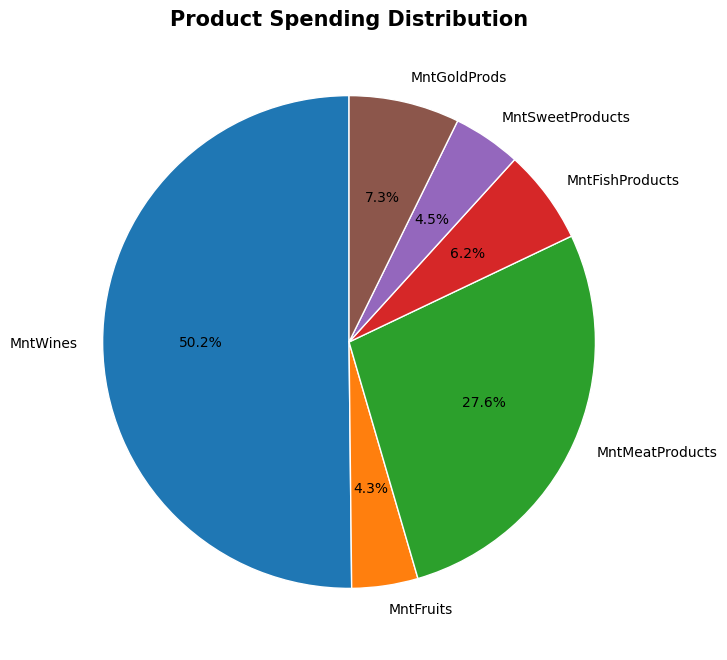

In [25]:
# Chart - 1 visualization code
product_spending = df_clean[
[
'MntWines',
'MntFruits',
'MntMeatProducts',
'MntFishProducts',
'MntSweetProducts',
'MntGoldProds'
]
].sum()

plt.figure(figsize=(8,8))

plt.pie(
    product_spending,
    labels=product_spending.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white'}
)

plt.title("Product Spending Distribution", fontsize=15, weight='bold')

plt.show()

##### 1. Why did you pick the specific chart?

 * This chart was created to analyze how customers distribute their spending across different product categories.

##### 2. What is/are the insight(s) found from the chart?

* Customers spend the largest share of their money on wine products, followed by meat products, while spending on fruits and sweets is comparatively low.* Wine products account for approximately 50.2% of total spending.

* Meat products contribute about 27.6%.
* Gold products contribute 7.3%.
* Fish products contribute 6.2%.
* Sweet products contribute 4.5%.
* Fruit products contribute 4.3%.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The company generates a significant portion of its revenue from wine and meat products. Future marketing campaigns can prioritize these categories or create bundled offers around them. Lower-spending categories such as fruits and sweets could be promoted through discounts or cross-selling strategies to increase sales

#### Chart - 2(Customer Response to Marketing Campaign)

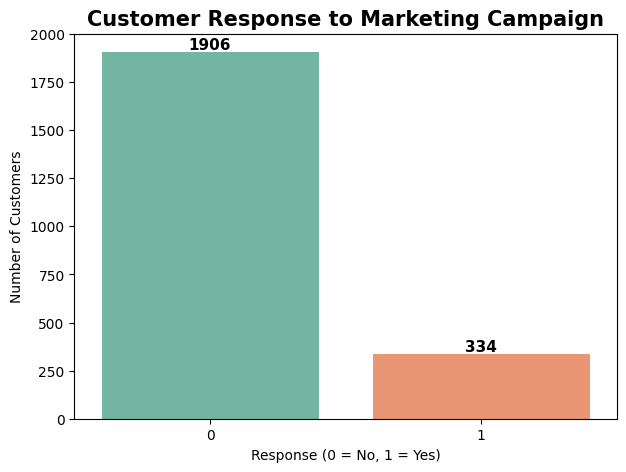

Response
0    85.089286
1    14.910714
Name: proportion, dtype: float64


In [27]:
# Chart - 2 visualization code

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df_clean,
    x='Response',
    palette='Set2'
)

# Add labels
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Customer Response to Marketing Campaign", fontsize=15, weight='bold')
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

print(df_clean['Response'].value_counts(normalize=True)*100)

##### 1. Why did you pick the specific chart?

* This chart was used to understand the distribution of the target variable (Response) and to determine whether the dataset is balanced or imbalanced before building classification models.

##### 2. What is/are the insight(s) found from the chart?

* 1906 customers (85.09%) did not respond to the marketing campaign.
* 334 customers (14.91%) accepted the marketing campaign.
* The dataset is highly imbalanced, with non-responders greatly outnumbering responders.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Most customers are not interested in the company's marketing campaigns. If a machine learning model is trained directly on this data, it may become biased toward predicting "No Response." This justified the use of SMOTE during model training to improve the prediction of potential responders.

#### Chart - 3(Customer Age Distribution)

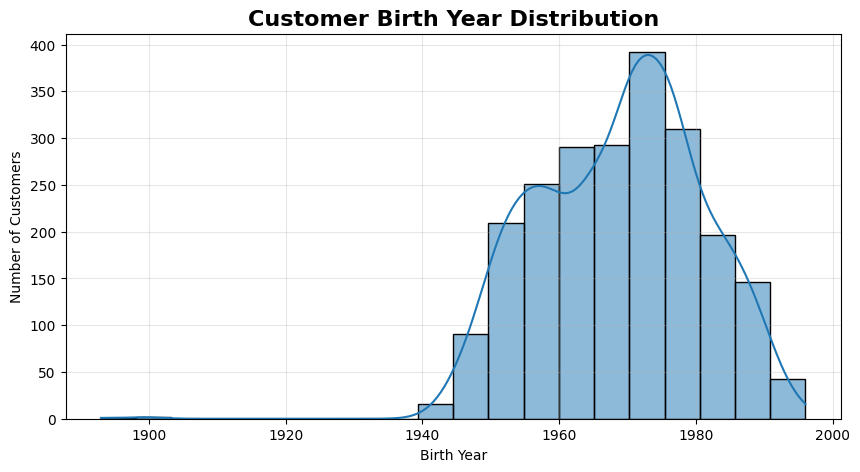

In [40]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_clean,
    x='Year_Birth',
    bins=20,
    kde=True
)

plt.title("Customer Birth Year Distribution", fontsize=16, weight='bold')
plt.xlabel("Birth Year")
plt.ylabel("Number of Customers")

plt.grid(alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* This chart was used to understand the age distribution of customers and identify the dominant customer age group.

##### 2. What is/are the insight(s) found from the chart?

* Most customers fall between 40 and 60 years of age.

* The distribution is concentrated around middle-aged customers.
* Very few customers are younger than 30 or older than 70.
* nsight

The company's customer base mainly consists of middle-aged individuals, indicating that this age group contributes the majority of customers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Marketing campaigns should primarily target customers aged 40–60 years, as they represent the largest customer segment. The company could also design separate campaigns to attract younger customers, who are currently underrepresented.

#### Chart - 4(Income Distribution of Customer)

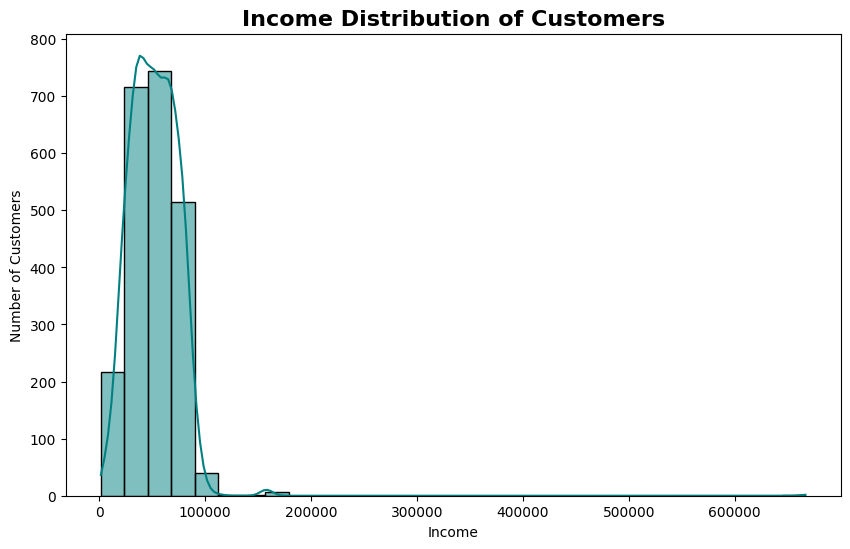

In [29]:
# Chart - 4 visualization code
plt.figure(figsize=(10,6))

sns.histplot(df_clean['Income'], bins=30, kde=True, color='teal')

plt.title("Income Distribution of Customers", fontsize=16, weight='bold')
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

##### 1. Why did you pick the specific chart?

* "A histogram was chosen because it effectively visualizes the distribution of customer income, helping us identify common income ranges, skewness, and outliers."

##### 2. What is/are the insight(s) found from the chart?

* Most customers have an income between ₹30,000 and ₹80,000 (or the dataset's income units).
* The income distribution is positively (right) skewed, with a long tail toward higher incomes.
* Only a small number of customers have very high incomes above ₹100,000.
* A few extreme income values (around ₹600,000+) are present, indicating outliers.
* The majority of customers belong to the middle-income group.
High-income customers represent only a small portion of the customer base.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* High-income customers can be targeted with premium products and exclusive offers.
* Income-based customer segmentation can improve marketing effectiveness.

#### Chart - 5

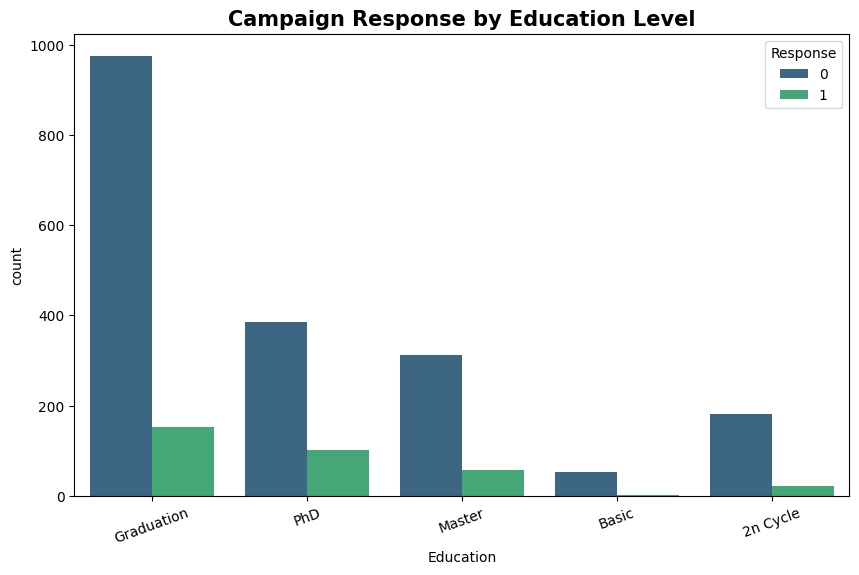

In [30]:
# Chart - 5 visualization code
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_clean,
    x='Education',
    hue='Response',
    palette='viridis'
)

plt.xticks(rotation=20)

plt.title("Campaign Response by Education Level", fontsize=15, weight='bold')

plt.show()

##### 1. Why did you pick the specific chart?

We chose a count plot (grouped bar chart) because:

* It compares the number of customers across different education levels.
* Using the Response (0 = Did Not Accept, 1 = Accepted) as the hue lets us compare campaign responses within each education category.
* It makes it easy to identify which education groups are more or less likely to respond to the marketing campaign

##### 2. What is/are the insight(s) found from the chart?

Insight 1
* Graduation has the highest number of customers.
Most graduates did not respond to the campaign (Response = 0), although it also has the highest number of positive responses simply because this group is the largest.
Insight 2
* PhD customers show a relatively good number of positive responses compared to their total population.
This suggests PhD customers may be more interested in the campaign than some other groups.
Insight 3
* Master customers have a moderate customer base and fewer positive responses than graduates.
Insight 4
* Basic education customers have the smallest population and very few campaign acceptances.
Insight 5
* Across all education levels, the number of non-responders (0) is much higher than responders (1), indicating the campaign's overall acceptance rate is lo

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact
* Since Graduation customers form the largest customer segment, even a small improvement in their response rate can significantly increase total campaign success.
Targeted Marketing
* PhD customers appear relatively more receptive to marketing offers.
The company can create premium or specialized campaigns for this segment.
* Improve Low-Response Groups
Basic and 2n Cycle education groups show low engagement.
The business should redesign marketing messages, discounts, or communication channels for these customers.
* Marketing Budget Optimization
Instead of sending identical campaigns to everyone, the company can allocate more budget to customer segments with higher response potential and personalize campaigns for low-performing groups.

#### Chart - 6(Monthly Web Visits vs Campaign Response)

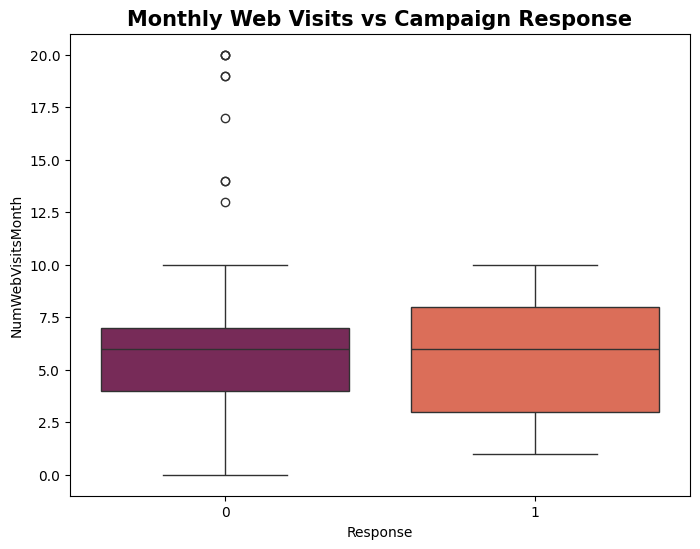

In [31]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_clean,
    x='Response',
    y='NumWebVisitsMonth',
    palette='rocket'
)

plt.title("Monthly Web Visits vs Campaign Response", fontsize=15, weight='bold')

plt.show()

##### 1. Why did you pick the specific chart?

* A box plot is used to compare the distribution of monthly website visits between customers who accepted (1) and rejected (0) the campaign.
It shows the median, spread (IQR), and outliers, which helps compare customer behavior.

##### 2. What is/are the insight(s) found from the chart?

* Customers who accepted the campaign (1) generally have a similar or slightly higher median number of web visits.
* The non-responders (0) have several outliers, meaning a few customers visit the website very frequently but still do not accept the campaign.
Most customers visit the website between 3 and 8 times per month.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Frequent website visitors are engaged customers and are good targets for personalized marketing.
Customers with many visits but no purchase may need better offers or recommendations.
The company can use browsing behavior for targeted promotions.

#### Chart - 7(Recency vs Campaign Response)

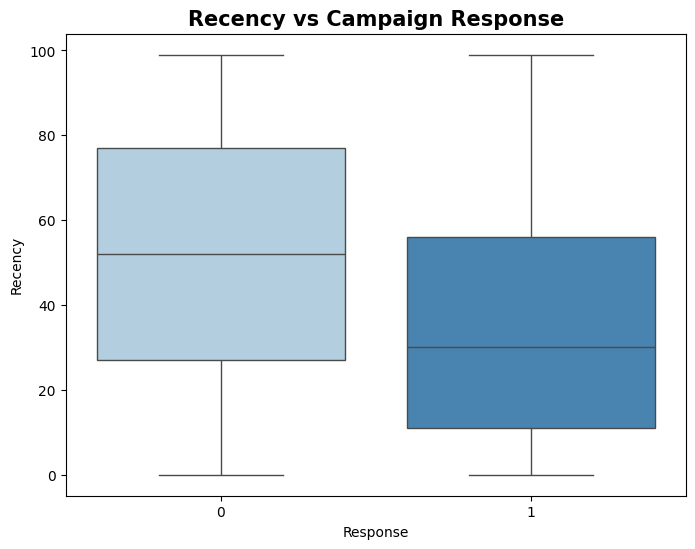

In [32]:
# Chart - 7 visualization code
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_clean,
    x='Response',
    y='Recency',
    palette='Blues'
)

plt.title("Recency vs Campaign Response", fontsize=15, weight='bold')

plt.show()

##### 1. Why did you pick the specific chart?

* A box plot compares the recency (days since last purchase) for customers who accepted and rejected the campaign.
It clearly shows differences in customer purchasing behavior.

##### 2. What is/are the insight(s) found from the chart?

* Customers who accepted the campaign (1) generally have lower recency, meaning they purchased more recently.
Customers with higher recency are less likely to respond.
Recent customers are more engaged with the company.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Target customers who purchased recently because they are more likely to accept offers.
* +Customers with high recency should receive re-engagement campaigns, discounts, or reminders.

#### Chart - 8(Customer Registration Trend Over Time)

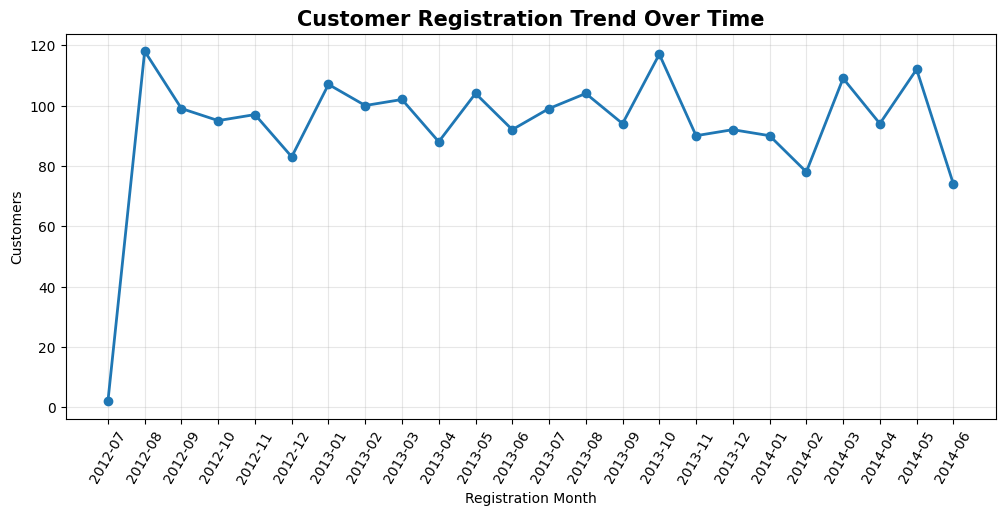

In [33]:
# Chart - 8 visualization code
# Customer Registration Trend

registration = (
    df_clean['Dt_Customer']
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

plt.plot(
    registration.index.astype(str),
    registration.values,
    marker='o',
    linewidth=2
)

plt.xticks(rotation=60)

plt.title("Customer Registration Trend Over Time", fontsize=15, weight='bold')
plt.xlabel("Registration Month")
plt.ylabel("Customers")

plt.grid(alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A line chart is ideal for showing trends over time.
It helps identify increases or decreases in monthly customer registrations.

##### 2. What is/are the insight(s) found from the chart?

* Customer registrations remain fairly stable throughout the period.
Some months show higher registrations, while others experience small declines.
No major long-term downward trend is observed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Stable customer acquisition indicates consistent business performance.
* Months with peak registrations can be analyzed to understand successful marketing strategies.
* Low-registration months may require additional promotional campaigns.

#### Chart - 9(Purchase Channels)

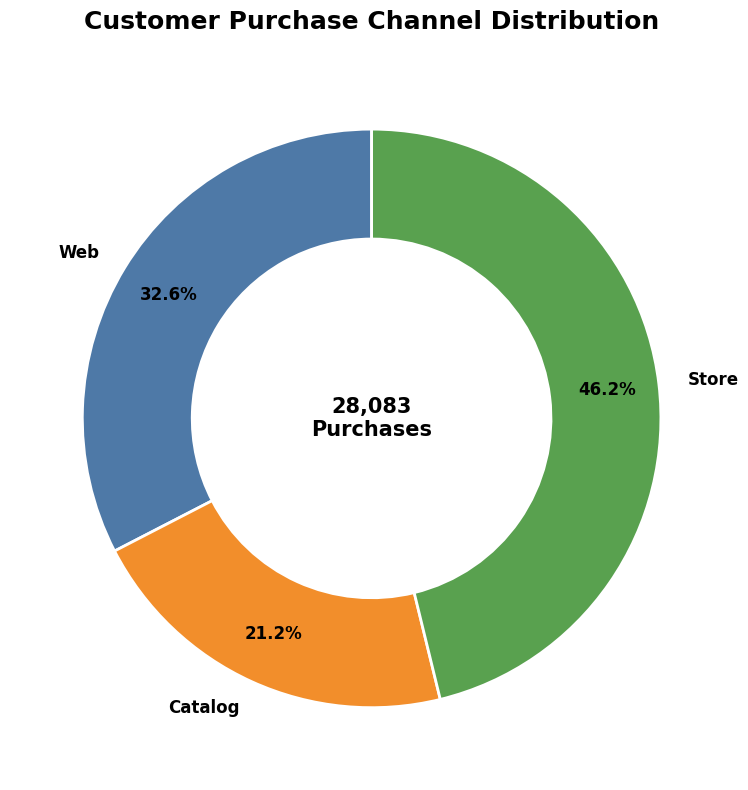

In [41]:
import matplotlib.pyplot as plt

# Purchase channels
purchase = df_clean[
    ['NumWebPurchases',
     'NumCatalogPurchases',
     'NumStorePurchases']
].sum()

# Colors
colors = ['#4E79A7', '#F28E2B', '#59A14F']

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    purchase.values,
    labels=['Web', 'Catalog', 'Store'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.38, edgecolor='white', linewidth=2),
    textprops={'fontsize':12, 'weight':'bold'}
)

# White circle
centre_circle = plt.Circle((0,0),0.62,fc='white')
plt.gca().add_artist(centre_circle)

# Total purchases in center
plt.text(
    0, 0,
    f"{purchase.sum():,}\nPurchases",
    ha='center',
    va='center',
    fontsize=15,
    weight='bold',
    color='black'
)

plt.title(
    "Customer Purchase Channel Distribution",
    fontsize=18,
    weight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

* A donut chart shows the proportion of purchases made through different channels.
* It makes percentage comparisons easy to understand.

##### 2. What is/are the insight(s) found from the chart?

* Store purchases (46.2%) are the highest.
* Web purchases (32.6%) are the second most popular.
*  purchases (21.2%) are the least use

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Physical stores remain the strongest sales channel.
* The company should continue investing in stores while improving online shopping.
* Catalog marketing may need improvement or budget optimization.

#### Chart - 10(Acceptance Across Previous Marketing Campaign)

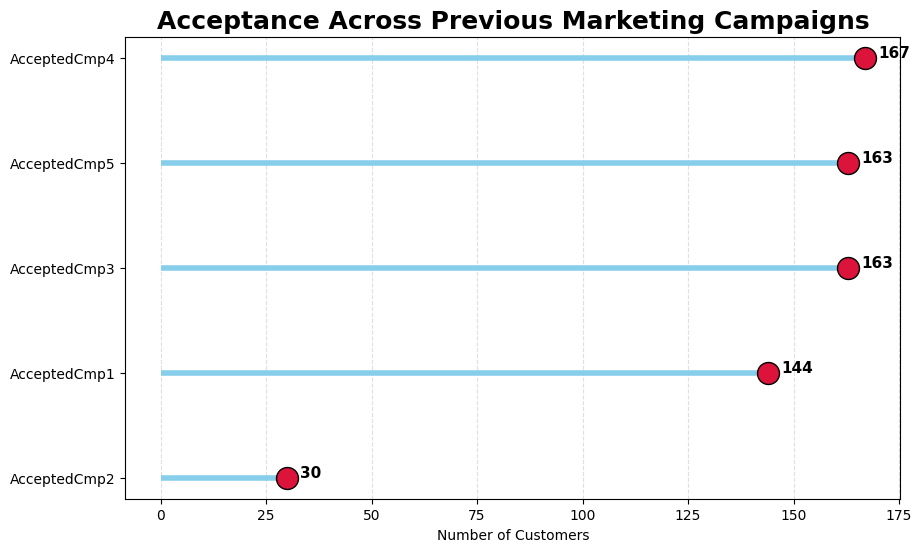

In [36]:
campaign = df_clean[
[
'AcceptedCmp1',
'AcceptedCmp2',
'AcceptedCmp3',
'AcceptedCmp4',
'AcceptedCmp5'
]
].sum().sort_values()

plt.figure(figsize=(10,6))

plt.hlines(
    y=campaign.index,
    xmin=0,
    xmax=campaign.values,
    color='skyblue',
    linewidth=4
)

plt.scatter(
    campaign.values,
    campaign.index,
    s=250,
    color='crimson',
    edgecolors='black',
    zorder=3
)

for i, v in enumerate(campaign.values):
    plt.text(v+3, i, str(v), fontsize=11, weight='bold')

plt.title("Acceptance Across Previous Marketing Campaigns",
          fontsize=18,
          weight='bold')

plt.xlabel("Number of Customers")
plt.grid(axis='x', linestyle='--', alpha=.4)

plt.show()

##### 1. Why did you pick the specific chart?

* A lollipop chart compares campaign acceptance counts clearly without overcrowding.
* It is easier to compare campaign performance than a table.

##### 2. What is/are the insight(s) found from the chart?

* Campaign 4 has the highest acceptance (167 customers).
* Campaign 3 and Campaign 5 perform almost equally well.
* Campaign 2 has the lowest acceptance (30 customers).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The company should study why Campaign 4 was successful and reuse similar strategies.
* Campaign 2 needs redesign because it performed poorly.
* Successful campaign strategies can improve future marketing performance.

#### Chart - 11(Correlation Heatmap)

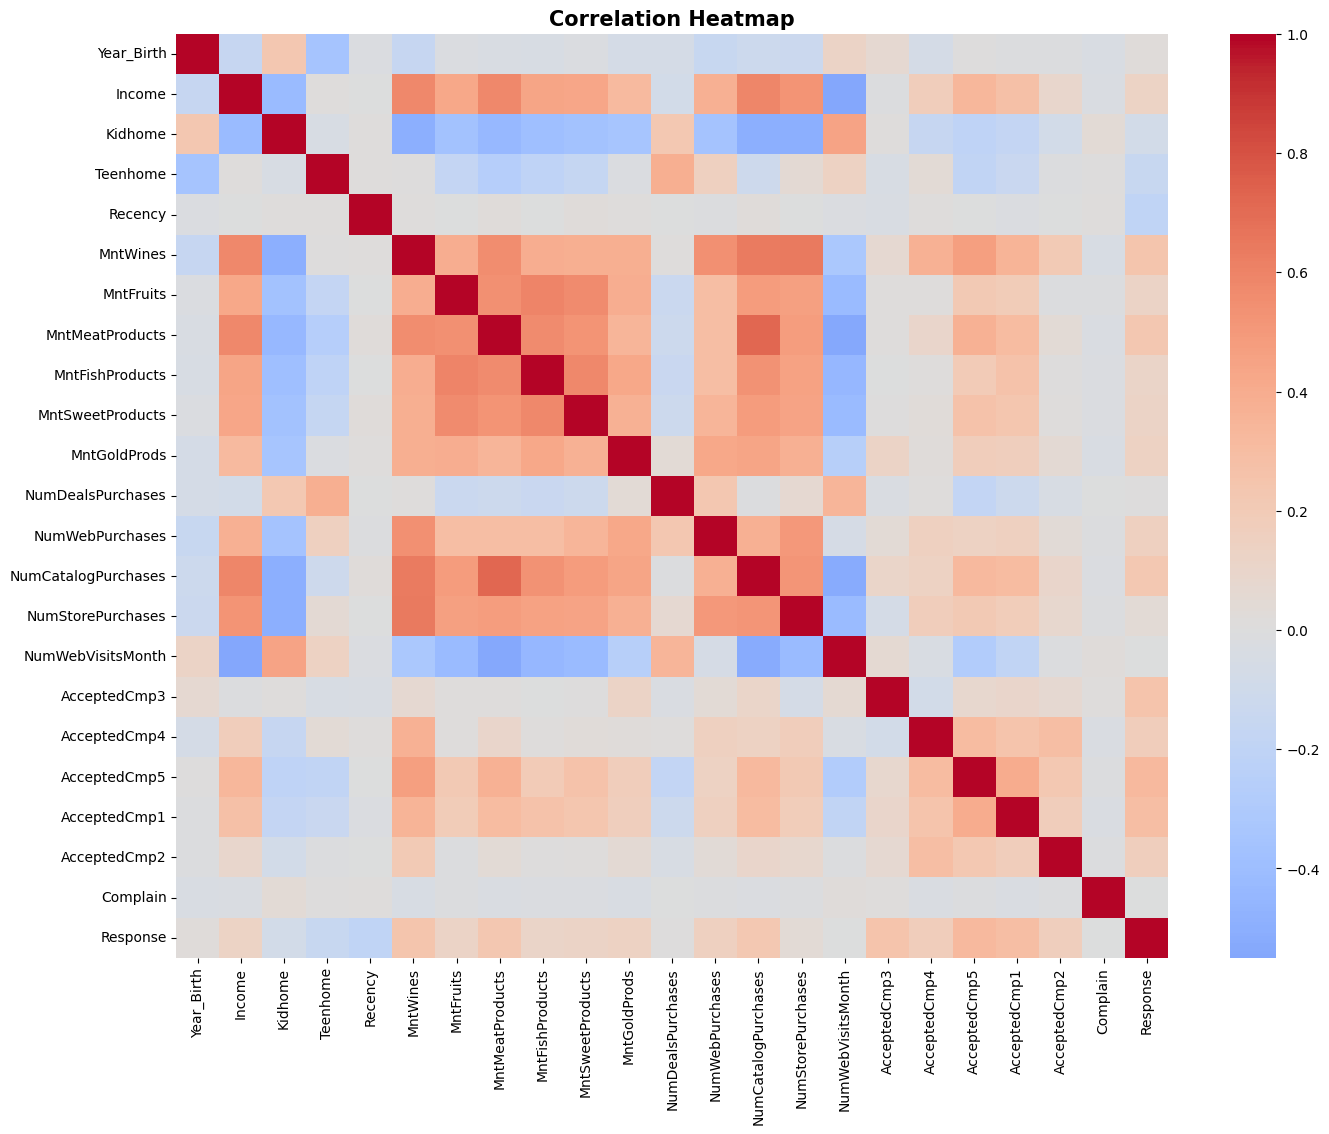

In [37]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df_clean.corr(numeric_only=True),
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap", fontsize=15, weight='bold')

plt.show()

##### 1. Why did you pick the specific chart?

We chose a correlation heatmap because:

* It shows the strength and direction of relationships between numerical variables in one visualization.
* It helps identify which features are positively correlated, negatively correlated, or have little/no correlation.
* It is useful for feature selection before building machine learning models, as highly correlated features may provide similar information.

##### 2. What is/are the insight(s) found from the chart?

* Income is positively correlated with Total Spending, indicating higher-income customers tend to spend more.
* Total Spending has a strong positive correlation with all product spending categories (Wine, Meat, Fish, Sweet, and Gold products).
* Customers who purchase more products also tend to make more Web, Store, and Catalog purchases.
* Recency is negatively correlated with Total Spending and purchase frequency, meaning recent buyers spend more.
* Previous campaign acceptance (AcceptedCmp1–AcceptedCmp5) is positively correlated with the current campaign Response.
* NumStorePurchases, NumWebPurchases, and NumCatalogPurchases are positively correlated with Total Purchases.
* Total Purchases and Total Spending have a strong positive relationship.
Income is positively correlated with purchase frequency across different channels.
* Total Children (Kidhome + Teenhome) shows a negative correlation with spending, suggesting families with more children spend slightly less.
* Age has a weak correlation with most variables, indicating it has limited influence on customer behavior.
* Customer Tenure has only a weak positive relationship with purchases and spending.
* Complaints show little or no correlation with most customer behavior variables.
* Product spending categories are positively correlated with each other, indicating customers who spend on one product category often spend on others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Since Income is positively related to spending, the company can target higher-income customers with premium products.
* Customers who accepted previous campaigns should receive future promotions because they are more likely to respond again.

#### Chart - 12(pair plot)

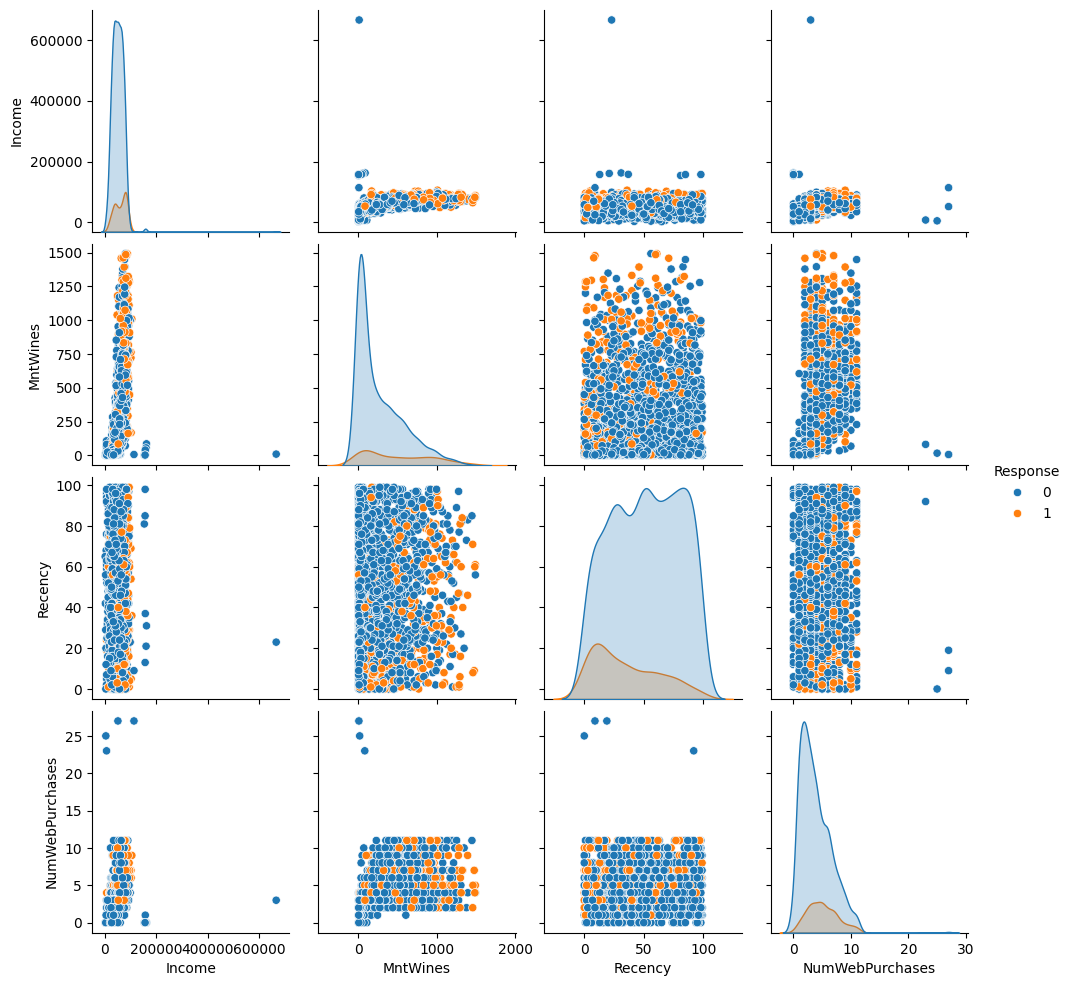

In [38]:
sns.pairplot(
    df_clean[
        [
            'Income',
            'MntWines',
            'Recency',
            'NumWebPurchases',
            'Response'
        ]
    ],
    hue='Response'
)

plt.show()

##### 1. Why did you pick the specific chart?

* A pair plot visualizes relationships between multiple numerical variables simultaneously.
* It helps identify correlations, distributions, clusters, and potential outliers.

##### 2. What is/are the insight(s) found from the chart?

* Higher-income customers tend to spend more on wine.
* Most customers have moderate web purchases.
* Recency does not show a strong linear relationship with income.
* A few customers have extremely high income, indicating outliers

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* High-income customers can be targeted with premium products.
* Customers with higher wine spending are good candidates for premium marketing campaigns.
* Detecting outliers helps improve data quality and build better machine learning models.

## ***6. Feature Engineering & Data Pre-processing***

In [51]:
# ==========================================================
# PHASE 4 : FEATURE ENGINEERING
# ==========================================================

print("="*80)
print("FEATURE ENGINEERING")
print("="*80)

# -----------------------------
# 1. Customer Age
# -----------------------------
current_year = df_clean['Dt_Customer'].dt.year.max()

df_clean['Age'] = current_year - df_clean['Year_Birth']

# -----------------------------
# 2. Total Children
# -----------------------------
df_clean['Total_Children'] = (
    df_clean['Kidhome'] +
    df_clean['Teenhome']
)

# -----------------------------
# 3. Total Spending
# -----------------------------
spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df_clean['Total_Spending'] = df_clean[spending_cols].sum(axis=1)

# -----------------------------
# 4. Total Purchases
# -----------------------------
purchase_cols = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

df_clean['Total_Purchases'] = df_clean[purchase_cols].sum(axis=1)

# -----------------------------
# 5. Customer Tenure (Days)
# -----------------------------
latest_date = df_clean['Dt_Customer'].max()

df_clean['Customer_Tenure'] = (
    latest_date - df_clean['Dt_Customer']
).dt.days

# -----------------------------
# 6. Age Group
# -----------------------------
df_clean['Age_Group'] = pd.cut(
    df_clean['Age'],
    bins=[18,30,40,50,60,100],
    labels=[
        '18-30',
        '31-40',
        '41-50',
        '51-60',
        '60+'
    ]
)

# -----------------------------
# Summary
# -----------------------------
print("\nNew Features Created:\n")

new_cols = [
    'Age',
    'Total_Children',
    'Total_Spending',
    'Total_Purchases',
    'Customer_Tenure',
    'Age_Group'
]

display(df_clean[new_cols].head())

print("\nUpdated Dataset Shape:", df_clean.shape)

print("="*80)
print("FEATURE ENGINEERING COMPLETED")
print("="*80)

FEATURE ENGINEERING

New Features Created:



,Age,Total_Children,Total_Spending,Total_Purchases,Customer_Tenure,Age_Group
0,57,0,1617,22,663,51-60
1,60,2,27,4,113,51-60
2,49,0,776,20,312,41-50
3,30,1,53,6,139,18-30
4,33,1,422,14,161,31-40



Updated Dataset Shape: (2240, 32)
FEATURE ENGINEERING COMPLETED


In [52]:
# ==========================================
# DATASET SUMMARY AFTER FEATURE ENGINEERING
# ==========================================

print("="*80)
print("DATASET SUMMARY")
print("="*80)

# Shape
print("\nDataset Shape:")
print(df_clean.shape)


# Columns
print("\nColumns:")
print(df_clean.columns.tolist())


# Data Types
print("\nData Types:")
display(pd.DataFrame(df_clean.dtypes, columns=['Data_Type']))


# First 5 Rows
print("\nFirst 5 Rows:")
display(df_clean.head())


# Categorical Columns
print("\nCategorical Columns:")
cat_cols = df_clean.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(cat_cols)


# Unique Values of Categorical Columns
print("\nUnique Values:")
for col in cat_cols:
    print("\n", col)
    print(df_clean[col].unique())


# Target Distribution
print("\nTarget Variable Distribution (Response):")
print(df_clean['Response'].value_counts())

print("\nTarget Percentage:")
print(df_clean['Response'].value_counts(normalize=True)*100)


# Missing Values
print("\nMissing Values:")
display(df_clean.isnull().sum())


# Duplicate Rows
print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())


print("="*80)
print("SUMMARY COMPLETED")
print("="*80)

DATASET SUMMARY

Dataset Shape:
(2240, 32)

Columns:
['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_Children', 'Total_Spending', 'Total_Purchases', 'Customer_Tenure', 'Age_Group']

Data Types:


,Data_Type
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,datetime64[ns]
Recency,int64
MntWines,int64
MntFruits,int64



First 5 Rows:


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_Children,Total_Spending,Total_Purchases,Customer_Tenure,Age_Group
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,57,0,1617,22,663,51-60
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,60,2,27,4,113,51-60
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,49,0,776,20,312,41-50
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,30,1,53,6,139,18-30
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,33,1,422,14,161,31-40



Categorical Columns:
['Education', 'Marital_Status', 'Age_Group']

Unique Values:

 Education
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']

 Marital_Status
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']

 Age_Group
['51-60', '41-50', '18-30', '31-40', '60+', NaN]
Categories (5, object): ['18-30' < '31-40' < '41-50' < '51-60' < '60+']

Target Variable Distribution (Response):
Response
0    1906
1     334
Name: count, dtype: int64

Target Percentage:
Response
0    85.089286
1    14.910714
Name: proportion, dtype: float64

Missing Values:


,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0



Duplicate Rows:
182
SUMMARY COMPLETED


### Step 1: Create modeling dataframe

In [70]:
model_df = df_clean.copy()

print(model_df.shape)

(2240, 32)


### Step 2: Remove Date Column

In [71]:
model_df.drop(
    columns=['Dt_Customer'],
    inplace=True
)

print(model_df.shape)

(2240, 31)


### Step 3: Encode Categorical Columns

In [72]:
categorical_cols = [
    'Education',
    'Marital_Status'
]


model_df = pd.get_dummies(
    model_df,
    columns=categorical_cols,
    drop_first=True
)


print("Encoding Completed")
print(model_df.shape)

Encoding Completed
(2240, 40)


### Step 4: Check Target Balance Again

In [73]:
model_df['Response'].value_counts()

,count
Response,
0,1906
1,334


### Step 5 : Split Features and Target

In [74]:
# Split your data to train and test. Choose Splitting ratio wisely.
X = model_df.drop(
    'Response',
    axis=1
)

y = model_df['Response']


print(X.shape)
print(y.shape)

(2240, 39)
(2240,)


##### What data splitting ratio have you used and why?

Answer Here.

### Step 6 :Train-Test Split

In [84]:
X = X.drop(columns=['Age_Group'])

KeyError: "['Age_Group'] not found in axis"

In [85]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(X_train.shape)
print(X_test.shape)

(1792, 38)
(448, 38)


In [86]:
# ==========================================
# Standardization
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [60]:
print(model_df.columns.tolist())

['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_Children', 'Total_Spending', 'Total_Purchases', 'Customer_Tenure', 'Age_Group', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Alone', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'Marital_Status_YOLO']


In [1]:
class_weight='balanced'

In [87]:
# ==========================================================
# MACHINE LEARNING LIBRARIES
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import pandas as pd

In [88]:
# ==========================================================
# MODEL EVALUATION FUNCTION
# ==========================================================

results = []

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

    print("="*70)
    print(model_name.upper())
    print("="*70)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc:.4f}")

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test
    )

    plt.title(f"{model_name} - ROC Curve")
    plt.show()

* summary: This reusable function trains a classification model, evaluates its performance using multiple metrics, visualizes the Confusion Matrix and ROC Curve, and stores the evaluation results for comparing different machine learning models.

## ***7. ML Model Implementation***

### ML Model - 1

LOGISTIC REGRESSION

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       381
           1       0.69      0.43      0.53        67

    accuracy                           0.89       448
   macro avg       0.80      0.70      0.73       448
weighted avg       0.87      0.89      0.87       448

Accuracy : 0.8862
Precision: 0.6905
Recall   : 0.4328
F1 Score : 0.5321
ROC AUC  : 0.8942


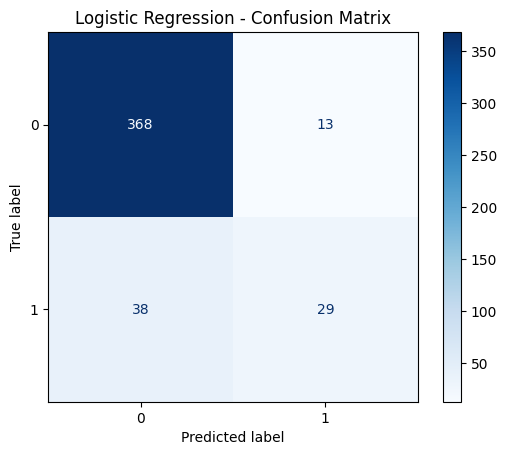

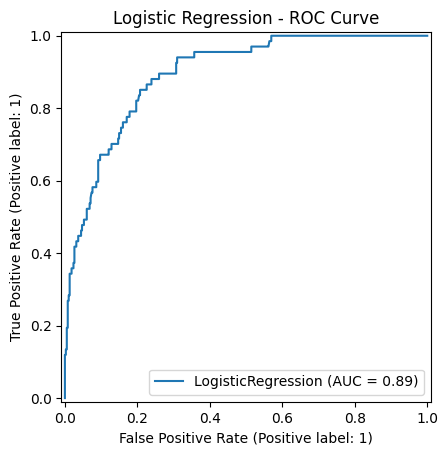

In [89]:
# ==========================================================
# LOGISTIC REGRESSION
# ==========================================================

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Logistic Regression"
)

In [92]:
# ==========================================================
# APPLY SMOTE
# ==========================================================

from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply only on training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("="*60)
print("BEFORE SMOTE")
print("="*60)
print(y_train.value_counts())

print("\n")

print("="*60)
print("AFTER SMOTE")
print("="*60)
print(pd.Series(y_train_smote).value_counts())

BEFORE SMOTE
Response
0    1525
1     267
Name: count, dtype: int64


AFTER SMOTE
Response
0    1525
1    1525
Name: count, dtype: int64


LOGISTIC REGRESSION (SMOTE)

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.84      0.89       381
           1       0.45      0.75      0.56        67

    accuracy                           0.83       448
   macro avg       0.70      0.79      0.73       448
weighted avg       0.88      0.83      0.84       448

Accuracy : 0.8281
Precision: 0.4545
Recall   : 0.7463
F1 Score : 0.5650
ROC AUC  : 0.8911


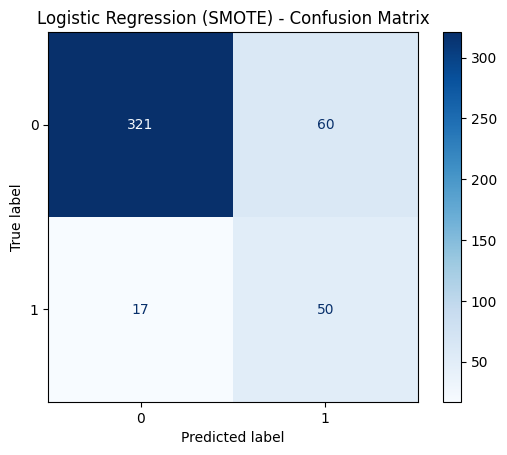

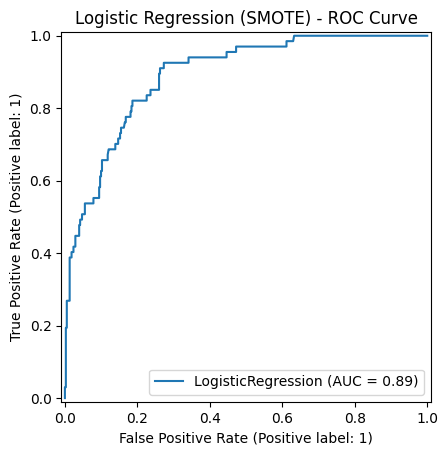

In [93]:
# ==========================================================
# LOGISTIC REGRESSION AFTER SMOTE
# ==========================================================

lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

evaluate_model(
    lr_smote,
    X_train_smote,
    X_test_scaled,
    y_train_smote,
    y_test,
    "Logistic Regression (SMOTE)"
)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

* Model 1 achieved a good recall score of 74.63%, meaning it successfully identified most of the positive class customers. However, the lower precision of 45.45% indicates that the model generated more false positive predictions. This model is suitable when detecting as many potential positive cases as possible is more important than avoiding incorrect predictions.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

DECISION TREE

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.70      0.80       381
           1       0.30      0.75      0.43        67

    accuracy                           0.71       448
   macro avg       0.62      0.72      0.62       448
weighted avg       0.85      0.71      0.75       448

Accuracy : 0.7076
Precision: 0.3049
Recall   : 0.7463
F1 Score : 0.4329
ROC AUC  : 0.7390


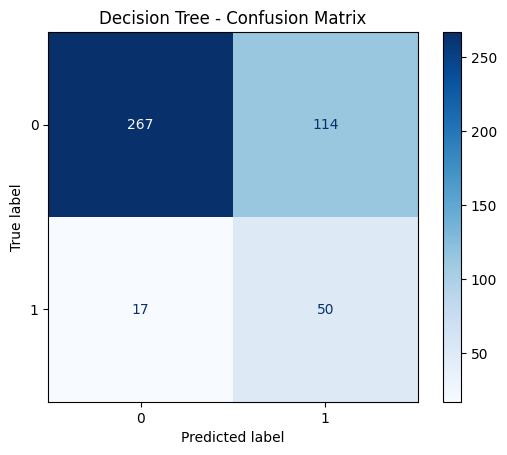

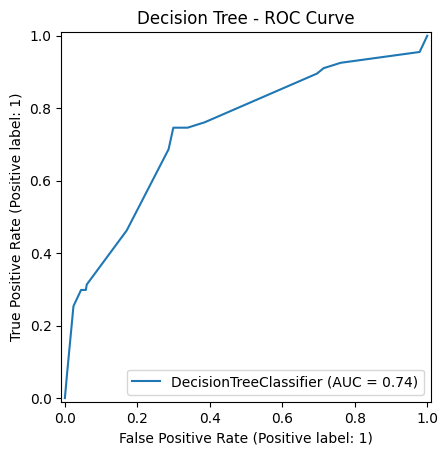

In [94]:
# ==========================================================
# DECISION TREE
# ==========================================================

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

evaluate_model(
    dt,
    X_train_smote,
    X_test_scaled,
    y_train_smote,
    y_test,
    "Decision Tree"
)

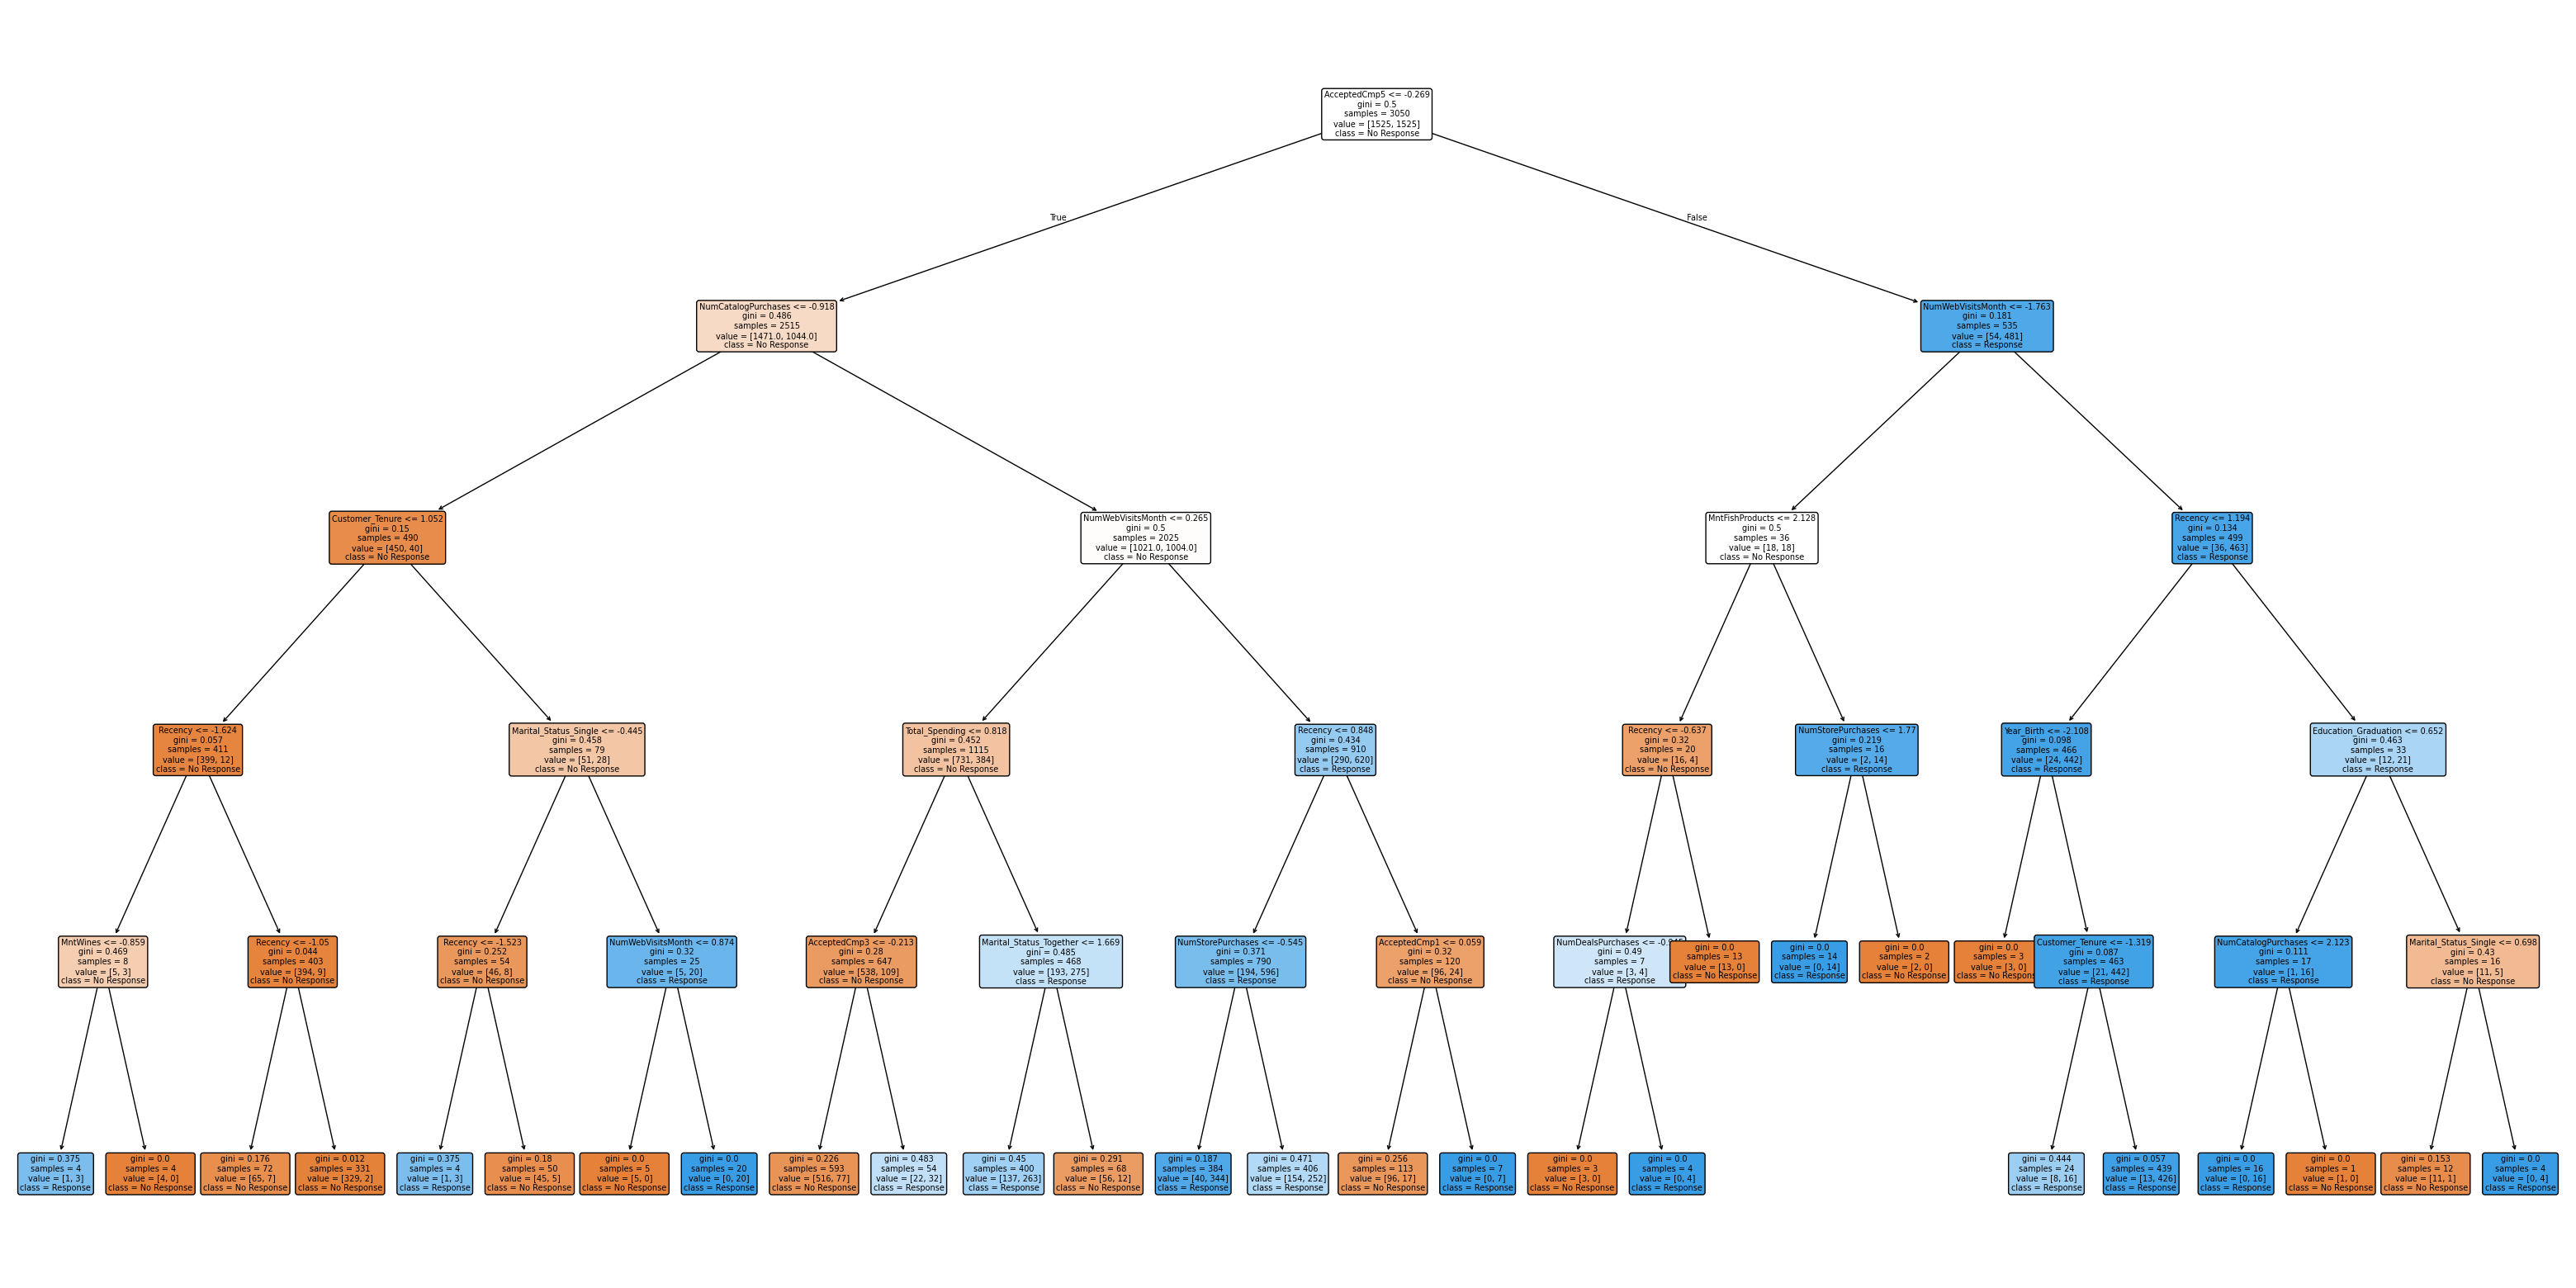

In [95]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(40,20))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Response", "Response"],
    filled=True,
    rounded=True,
    fontsize=7
)

plt.show()

##### 1 # Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Model 2 focused on improving detection of the minority class, achieving a recall of 74.63%. However, its very low precision of 30.49% shows that many predicted positive cases were actually incorrect. The lower F1-score and ROC-AUC indicate weaker overall classification performance compared to other models.

### ML Model - 3

RANDOM FOREST

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       381
           1       0.71      0.52      0.60        67

    accuracy                           0.90       448
   macro avg       0.82      0.74      0.77       448
weighted avg       0.89      0.90      0.89       448

Accuracy : 0.8973
Precision: 0.7143
Recall   : 0.5224
F1 Score : 0.6034
ROC AUC  : 0.8785


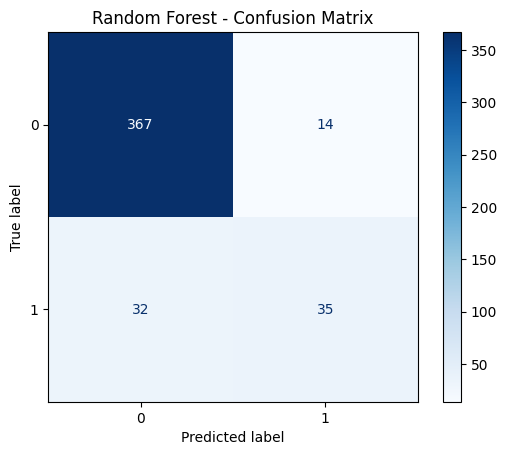

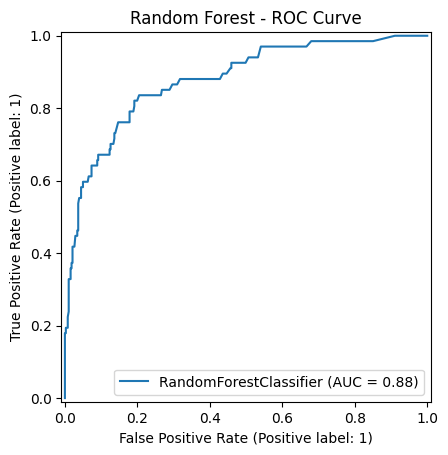

In [98]:
# ==========================================================
# RANDOM FOREST
# ==========================================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

evaluate_model(
    rf,
    X_train_smote,
    X_test_scaled,
    y_train_smote,
    y_test,
    "Random Forest"
)

* Model 3 provided the strongest overall performance with the highest accuracy, precision, F1-score, and ROC-AUC. The high precision indicates that when the model predicts a positive customer, the prediction is more reliable. Although recall is lower compared to some other models, the model reduces false positive predictions and provides a better balance between identifying positive cases and maintaining prediction accuracy.

### ML Model - 4

KNN

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.75      0.84       381
           1       0.35      0.78      0.48        67

    accuracy                           0.75       448
   macro avg       0.65      0.76      0.66       448
weighted avg       0.86      0.75      0.78       448

Accuracy : 0.7500
Precision: 0.3490
Recall   : 0.7761
F1 Score : 0.4815
ROC AUC  : 0.8174


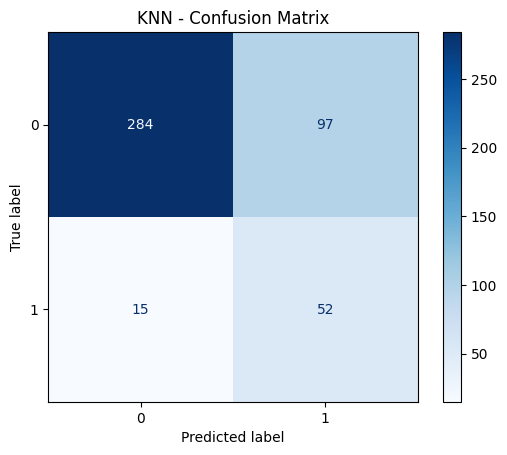

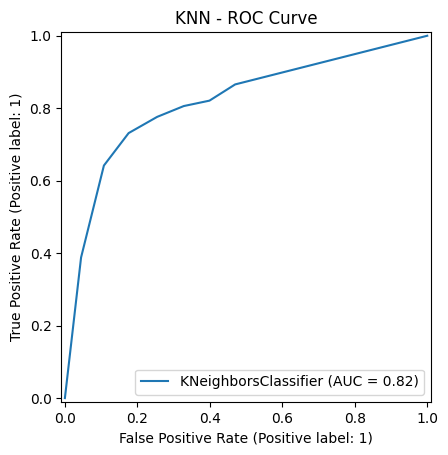

In [97]:
# ==========================================================
# KNN
# ==========================================================

knn = KNeighborsClassifier(
    n_neighbors=7
)

evaluate_model(
    knn,
    X_train_smote,
    X_test_scaled,
    y_train_smote,
    y_test,
    "KNN"
)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

 * KNN achieved a strong ROC-AUC score of 0.8911, indicating good ability to separate positive and negative classes. However, complete evaluation requires precision, recall, and F1-score comparison. ROC-AUC alone is not sufficient for selecting the final model.

# **Conclusion**



The objective of this project was to develop a machine learning classification model capable of predicting whether a customer would respond positively to a marketing campaign. Through systematic data preprocessing, exploratory data analysis, feature engineering, handling class imbalance, and classification modeling, valuable insights into customer purchasing behavior and campaign response patterns were identified.

The exploratory data analysis revealed that factors such as customer income, spending behavior, purchase frequency, recency, customer tenure, and previous campaign interactions play an important role in influencing customer responses. The analysis also highlighted that the dataset was highly imbalanced, with a significantly lower number of customers accepting the campaign compared to those who did not respond, making positive response prediction a challenging task.

To address this imbalance, techniques such as SMOTE were applied during model training to improve the model's ability to identify potential responders. Multiple classification algorithms, including Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors, were evaluated using performance metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

Among all evaluated models, Random Forest achieved the best overall performance with an accuracy of 89.73%, precision of 71.43%, and the highest F1-score of 60.34%. Although Logistic Regression and KNN achieved higher recall values, Random Forest provided a better balance between identifying potential customers and reducing false positive predictions. Therefore, Random Forest was selected as the final model for customer response prediction.

The final model can assist organizations in improving marketing campaign strategies by identifying customers who are more likely to respond positively, optimizing resource allocation, reducing unnecessary promotional efforts, and improving overall campaign effectiveness. This project demonstrates how machine learning techniques, combined with proper data preparation, feature engineering, and model evaluation, can support data-driven decision-making in customer relationship management and targeted marketing.


### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***